# Rectified Flow (1-RF) 完整可运行版

把原仓库 1-Rectified Flow 阶段的全部代码（`model.py` + `rectified_flow.py` + `train.py` + `infer.py`）重构进本 notebook，**不依赖任何项目文件**，从上到下运行即可。

适用场景：Google Colab（网页版或 VSCode 的 Colab 扩展）、本地 Jupyter。

核心就三个公式（老司机开车理论：路线、车、司机）：

```python
# 路线：噪声 x_0 和图像 x_1 之间线性插值
x_t = t * x_1 + (1 - t) * x_0

# 司机要学的是目标速度：匀速直线运动
target_velocity = x_1 - x_0

# 车：推理时用 Euler 法沿速度场更新
x_next = x_t + v * dt
```

In [1]:
# Colab 自带 torch/torchvision/matplotlib，无需安装；本地环境缺啥取消注释装啥
# !pip install -q torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 设备自动检测：Colab 免费版是 T4 GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## 挂载 Google Drive（统一输出目录）

所有结果（权重 / 图片 / 曲线）统一保存到网盘 `MyDrive/rectified-flow-output/`。首次运行会输出一个授权链接，点击后在浏览器里登录并授权即可。

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')  # 首次运行会要求授权，按提示在浏览器里登录

# 统一输出目录：权重 / 图片 / 曲线全部存这里
DRIVE_OUT = '/content/drive/MyDrive/rectified-flow-output'
os.makedirs(os.path.join(DRIVE_OUT, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(DRIVE_OUT, 'images'), exist_ok=True)
print('输出目录:', DRIVE_OUT)

Mounted at /content/drive
输出目录: /content/drive/MyDrive/rectified-flow-output


## ① RectifiedFlow 核心类（对应 `rectified_flow.py`）

三要素：
- **路线** `create_flow`：在噪声 `x_0` 和图像 `x_1` 之间按时间 `t` 插值
- **车** `euler`：ODE 迭代公式 `x_{t+dt} = x_t + v·dt`
- **司机** `mse_loss`：模型学的是目标速度 `x_1 - x_0`

In [3]:
class RectifiedFlow:
    # 车：图像生成一个迭代公式 ODE f(t+dt) = f(t) + dt*f'(t)
    def euler(self, x_t, v, dt):
        """ 使用欧拉方法计算下一个时间步长的值
        x_t: 当前的值 [B, C, H, W]
        v: 当前的速度 [B, C, H, W]
        dt: 时间步长
        """
        return x_t + v * dt

    # 路线
    def create_flow(self, x_1, t, x_0=None):
        """ 用 x_t = t * x_1 + (1 - t) * x_0 构建 x_0 到 x_1 的流
        x_1: 原始图像，x_0: 噪声图像（标准高斯），t: 时间 [0, 1]
        返回 (x_t, x_0)，x_0 未传时现采样高斯噪声
        """
        if x_0 is None:
            x_0 = torch.randn_like(x_1)  # 1-RF 训练时噪声现采即可，用完即弃
        t = t[:, None, None, None]  # [B] -> [B, 1, 1, 1]
        x_t = t * x_1 + (1 - t) * x_0
        return x_t, x_0

    # 司机
    def mse_loss(self, v, x_1, x_0):
        """ L = MSE(x_1 - x_0 - v(t))，匀速直线运动的目标速度是 x_1 - x_0 """
        return F.mse_loss(x_1 - x_0, v)

## ② MiniUnet 模型（对应 `model.py`）

结构：两个下采样 block → 一个中间 block → 两个上采样 block（带 skip 拼接）。

两个条件注入方式（都编码成 `[B, dim]` 加到特征上）：
- `time_emb`：时间 `t` 的正弦编码，让模型感知当前插值到哪了
- `label_emb`：类别标签的正弦编码，实现条件生成；`y = -1` 时置零 = 无条件

> 对应仓库文件 [model.py](rectified-flow-main/model.py)，与原始代码完全一致，仅去掉 `__main__` 测试段。

In [4]:
class DownLayer(nn.Module):
    """MiniUnet 的下采样层 Resnet"""
    def __init__(self, in_channels, out_channels, time_emb_dim=16, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        self.fc = nn.Linear(time_emb_dim, in_channels)  # 时间编码换通道 [B, dim] -> [B, in_channels]
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.downsample = downsample
        if downsample:
            self.pool = nn.MaxPool2d(2)

    def forward(self, x, temb):
        res = x
        x += self.fc(temb)[:, :, None, None]  # 时间条件加到每个空间位置
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        if self.shortcut is not None:
            res = self.shortcut(res)
        x = x + res
        if self.downsample:
            x = self.pool(x)
        return x


class UpLayer(nn.Module):
    """MiniUnet 的上采样层"""
    def __init__(self, in_channels, out_channels, time_emb_dim=16, upsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        self.fc = nn.Linear(time_emb_dim, in_channels)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.upsample = upsample
        if upsample:
            self.upsample = nn.Upsample(scale_factor=2)

    def forward(self, x, temb):
        if self.upsample:
            x = self.upsample(x)
        res = x
        x += self.fc(temb)[:, :, None, None]
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        if self.shortcut is not None:
            res = self.shortcut(res)
        return x + res


class MiddleLayer(nn.Module):
    """MiniUnet 的中间层"""
    def __init__(self, in_channels, out_channels, time_emb_dim=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        self.fc = nn.Linear(time_emb_dim, in_channels)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x, temb):
        res = x
        x += self.fc(temb)[:, :, None, None]
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        if self.shortcut is not None:
            res = self.shortcut(res)
        return x + res


class MiniUnet(nn.Module):
    """对 MNIST (28×28) 做生成的迷你 UNet：两个下采样 + 一个中间 + 两个上采样"""
    def __init__(self, base_channels=16, time_emb_dim=None):
        super().__init__()
        if time_emb_dim is None:
            self.time_emb_dim = base_channels
        self.base_channels = base_channels
        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)

        self.down1 = nn.ModuleList([
            DownLayer(base_channels, base_channels * 2, time_emb_dim=self.time_emb_dim, downsample=False),
            DownLayer(base_channels * 2, base_channels * 2, time_emb_dim=self.time_emb_dim),
        ])
        self.maxpool1 = nn.MaxPool2d(2)
        self.down2 = nn.ModuleList([
            DownLayer(base_channels * 2, base_channels * 4, time_emb_dim=self.time_emb_dim, downsample=False),
            DownLayer(base_channels * 4, base_channels * 4, time_emb_dim=self.time_emb_dim),
        ])
        self.maxpool2 = nn.MaxPool2d(2)
        self.middle = MiddleLayer(base_channels * 4, base_channels * 4, time_emb_dim=self.time_emb_dim)

        self.upsample1 = nn.Upsample(scale_factor=2)
        self.up1 = nn.ModuleList([
            UpLayer(base_channels * 8, base_channels * 2, time_emb_dim=self.time_emb_dim, upsample=False),  # concat
            UpLayer(base_channels * 2, base_channels * 2, time_emb_dim=self.time_emb_dim),
        ])
        self.upsample2 = nn.Upsample(scale_factor=2)
        self.up2 = nn.ModuleList([
            UpLayer(base_channels * 4, base_channels, time_emb_dim=self.time_emb_dim, upsample=False),
            UpLayer(base_channels, base_channels, time_emb_dim=self.time_emb_dim),
        ])
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=1, padding=0)

    def time_emb(self, t, dim):
        """时间 t 的正弦编码，让模型感知 x_t 所在的时刻。
        输入 t: [B]（取值范围 [0, 1]），输出 [B, dim]
        """
        t = t * 1000  # 映射到 [0, 1000]
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(t.device)
        return torch.cat([torch.sin(t[:, None] / freqs), torch.cos(t[:, None] / freqs)], dim=-1)

    def label_emb(self, y, dim):
        """类别标签的正弦编码，与 time_emb 同维度，可直接相加注入"""
        y = y * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(y.device)
        return torch.cat([torch.sin(y[:, None] / freqs), torch.cos(y[:, None] / freqs)], dim=-1)

    def forward(self, x, t, y=None):
        """x: [B, 1, 28, 28]，t: [B]，y: [B] 标签（-1 = 无条件）
        返回预测的速度场 [B, 1, 28, 28]
        """
        x = self.conv_in(x)
        temb = self.time_emb(t, self.base_channels)
        if y is not None:
            if len(y.shape) == 1:  # label 形式
                yemb = self.label_emb(y, self.base_channels)
                yemb[y == -1] = 0.0  # -1 表示无条件，编码置零
                temb += yemb  # 时间条件 + 标签条件一起注入
            else:  # 文本形式，暂不支持
                pass

        # 下采样
        for layer in self.down1:
            x = layer(x, temb)
        x1 = x
        x = self.maxpool1(x)
        for layer in self.down2:
            x = layer(x, temb)
        x2 = x
        x = self.maxpool2(x)

        # 中间层
        x = self.middle(x, temb)

        # 上采样（skip 拼接）
        x = torch.cat([self.upsample1(x), x2], dim=1)
        for layer in self.up1:
            x = layer(x, temb)
        x = torch.cat([self.upsample2(x), x1], dim=1)
        for layer in self.up2:
            x = layer(x, temb)

        return self.conv_out(x)

## ③ 数据准备（MNIST）

Colab 云端会自动下载 MNIST 到运行时本地（`./data`），约 60MB，无需手动处理。

1-RF 阶段只需要图像的 `x_1`，噪声 `x_0` 在训练时现采样（对比：Reflow 阶段需要固定配对的噪声，才用得上自定义数据集）。

In [5]:
transform = Compose([ToTensor()])  # PIL -> tensor，值域 [0, 1]

train_set = MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(train_set, batch_size=16, shuffle=True)
print(f'MNIST 训练集样本数: {len(train_set)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 52.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]

MNIST 训练集样本数: 60000


## ④ 训练（对应 `train.py`）

每步做的事：
1. 采样图像 `x_1` 和随机时间 `t`
2. 现采样高斯噪声 `x_0`，插值出 `x_t`（**路线**）
3. 模型预测速度场 `v_pred`（**司机**）
4. 用目标速度 `x_1 - x_0` 算 MSE（**司机**）

`use_cfg=True` 时，每步把数据复制一份、标签替换为 `-1`，以 50% 比例训练无条件路径，推理时才能用 CFG 引导。

> T4 上 `base_channels=64, batch_size=16, use_cfg=True` 一轮约 10-15 分钟。想快速验证用 `epochs=10`，复现仓库效果改 `epochs=50`。

In [6]:
# ============ 训练参数（原 yaml 配置内联化） ============
base_channels = 64      # 通道数，越大容量越大
epochs = 10             # 快速验证用 10；复现仓库效果改 50
batch_size = 16
lr = 1e-4
lr_adjust_epoch = 10    # 到第几个 epoch 学习率降为 1/10
use_cfg = True          # Classifier-free Guidance 条件生成训练
checkpoint_save_interval = 5  # 每几个 epoch 存一次权重

# ============ 训练准备 ============
model = MiniUnet(base_channels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_adjust_epoch, gamma=0.1)
rf = RectifiedFlow()
loss_list = []

# ============ 训练循环 ============
for epoch in range(epochs):
    for batch, data in enumerate(dataloader):
        x_1, y = data  # x_1 原始图像，y 标签（CFG 用）
        t = torch.rand(x_1.size(0))  # 均匀采样 [0, 1] 的时间

        x_t, x_0 = rf.create_flow(x_1, t)  # 路线：插值出中间状态
        x_t, x_0, x_1, t = (a.to(device) for a in (x_t, x_0, x_1, t))

        if use_cfg:
            # 复制一份，把标签替换成 -1（无条件），50% 数据走无条件路径
            x_t = torch.cat([x_t, x_t.clone()], dim=0)
            t = torch.cat([t, t.clone()], dim=0)
            y = torch.cat([y, -torch.ones_like(y)], dim=0)
            x_1 = torch.cat([x_1, x_1.clone()], dim=0)
            x_0 = torch.cat([x_0, x_0.clone()], dim=0)
            y = y.to(device)
        else:
            y = None

        v_pred = model(x=x_t, t=t, y=y)  # 司机：预测速度场
        loss = rf.mse_loss(v_pred, x_1, x_0)  # 目标速度 = x_1 - x_0

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            print(f'[Epoch {epoch}] [batch {batch}] loss: {loss.item():.4f}')
        loss_list.append(loss.item())
    scheduler.step()

    # 定期存权重（直接写入 Google Drive，运行时重置也不丢）
    if epoch % checkpoint_save_interval == 0 or epoch == epochs - 1:
        torch.save({'model': model.state_dict(), 'epoch': epoch, 'loss_list': loss_list},
                   os.path.join(DRIVE_OUT, 'checkpoints', 'miniunet_1rf.pth'))
        print(f'[Epoch {epoch}] checkpoint saved to Drive')

print('training done')

[Epoch 0] [batch 0] loss: 1.7097
[Epoch 0] [batch 100] loss: 0.4160
[Epoch 0] [batch 200] loss: 0.3295
[Epoch 0] [batch 300] loss: 0.1911
[Epoch 0] [batch 400] loss: 0.1779
[Epoch 0] [batch 500] loss: 0.1434
[Epoch 0] [batch 600] loss: 0.1499
[Epoch 0] [batch 700] loss: 0.1421
[Epoch 0] [batch 800] loss: 0.1322
[Epoch 0] [batch 900] loss: 0.1500
[Epoch 0] [batch 1000] loss: 0.1122
[Epoch 0] [batch 1100] loss: 0.1332
[Epoch 0] [batch 1200] loss: 0.1153
[Epoch 0] [batch 1300] loss: 0.1156
[Epoch 0] [batch 1400] loss: 0.1247
[Epoch 0] [batch 1500] loss: 0.1429
[Epoch 0] [batch 1600] loss: 0.1091
[Epoch 0] [batch 1700] loss: 0.1271
[Epoch 0] [batch 1800] loss: 0.1720
[Epoch 0] [batch 1900] loss: 0.1137
[Epoch 0] [batch 2000] loss: 0.1437
[Epoch 0] [batch 2100] loss: 0.1135
[Epoch 0] [batch 2200] loss: 0.1171
[Epoch 0] [batch 2300] loss: 0.0999
[Epoch 0] [batch 2400] loss: 0.0994
[Epoch 0] [batch 2500] loss: 0.0953
[Epoch 0] [batch 2600] loss: 0.1312
[Epoch 0] [batch 2700] loss: 0.1044
[Epo

## ⑤ 推理（对应 `infer.py`）

从标准高斯噪声出发，用训练好的速度场做 Euler 迭代，`step` 步后噪声就走到了图像。

CFG 公式：`v = v_uncond + cfg_scale × (v_cond - v_uncond)`，需要同时跑一次无条件、一次有条件的前向。

> 原仓库用 `cv2` 存图，这里改成返回 numpy 数组用 matplotlib 直接显示。

In [7]:
@torch.no_grad()
def infer(model, num_imgs=10, step=20, y=None, cfg_scale=7.0, device='cuda'):
    """用训练好的模型从高斯噪声生成图像
    num_imgs: 生成数量
    step: Euler 迭代步数（10 步效果就很好）
    y: 条件标签 [num_imgs]，None = 无条件生成
    cfg_scale: CFG 缩放因子，越大越贴合条件、多样性越低
    返回 [num_imgs, 28, 28] 的 numpy 数组（值域 [0,1]）
    """
    model.eval()
    rf = RectifiedFlow()
    if y is not None:
        y = y.to(device)

    imgs = []
    for i in range(num_imgs):
        dt = 1.0 / step
        x_t = torch.randn(1, 1, 28, 28).to(device)  # 起点 x_0：标准高斯噪声
        if y is not None:
            y_i = y[i].unsqueeze(0)

        for j in range(step):
            t = torch.tensor([j * dt]).to(device)
            if y is not None:
                v_uncond = model(x=x_t, t=t)          # 无条件速度场
                v_cond = model(x=x_t, t=t, y=y_i)     # 有条件速度场
                v_pred = v_uncond + cfg_scale * (v_cond - v_uncond)  # CFG 合并
            else:
                v_pred = model(x=x_t, t=t)
            x_t = rf.euler(x_t, v_pred, dt)  # 车：x_{t+dt} = x_t + v·dt
        imgs.append(x_t[0, 0].clamp(0, 1).cpu().numpy())  # 终点即生成图
    return imgs

images saved to Drive: /content/drive/MyDrive/rectified-flow-output/images


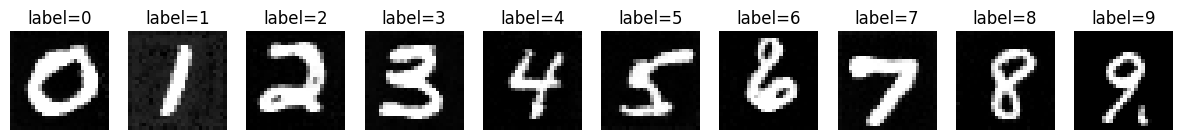

In [8]:
# 每个数字生成一张，CFG 引导
y = torch.arange(10)
imgs = infer(model, num_imgs=10, step=20, y=y, cfg_scale=7.0, device=device)

# 图片直接保存到 Google Drive
for i, img in enumerate(imgs):
    plt.imsave(os.path.join(DRIVE_OUT, 'images', f'{i}.png'), img, cmap='gray')
print('images saved to Drive:', os.path.join(DRIVE_OUT, 'images'))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, img in enumerate(imgs):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'label={i}')
    axes[i].axis('off')
plt.show()

# 想对比无条件生成：
# uncond = infer(model, num_imgs=10, step=20, y=None, device=device)

## ⑥ Loss 曲线

对应仓库的 `plot_loss_curve.py`，读取训练时记录的 `loss_list` 直接画。

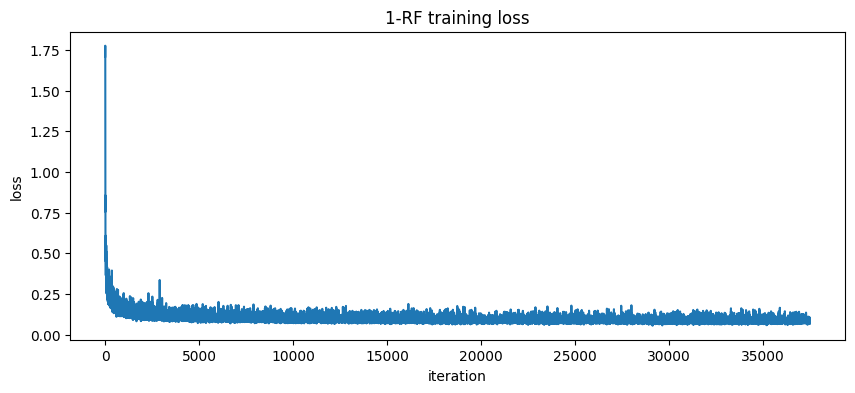

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('1-RF training loss')
plt.savefig(os.path.join(DRIVE_OUT, 'loss_curve.png'), dpi=150, bbox_inches='tight')  # 曲线图也存到 Drive
plt.show()

## ⑦ 结果统一存到 Google Drive

所有产物（模型权重、生成图片、loss 曲线）在运行时就**实时写入**网盘，即使 Colab 运行时重置也不会丢：

```text
MyDrive/rectified-flow-output/      ← DRIVE_OUT
├── checkpoints/miniunet_1rf.pth    # 训练权重（每 N 个 epoch 覆盖保存）
├── images/0.png ~ 9.png            # 生成图片（每个数字一张）
└── loss_curve.png                  # loss 曲线图
```

下载到本地：浏览器打开 drive.google.com → 找到 `MyDrive/rectified-flow-output` → 右键下载。

> 提示：只想在本地跑（不想挂 Drive）的话，把挂载 cell 里的 `DRIVE_OUT` 改成任意本地路径（如 `'./output'`）即可，其余 cell 不用动。

In [10]:
# 随时查看 Drive 输出目录里已保存的产物
!ls -R {DRIVE_OUT}

/content/drive/MyDrive/rectified-flow-output:
checkpoints  images  loss_curve.png

/content/drive/MyDrive/rectified-flow-output/checkpoints:
miniunet_1rf.pth

/content/drive/MyDrive/rectified-flow-output/images:
0.png  1.png  2.png  3.png  4.png  5.png  6.png  7.png	8.png  9.png


## 下一步

想继续学 Reflow（2-RF）的话：用本 notebook 的 `infer` 生成配对 (噪声, 图像) 数据，再训练第二个模型把轨迹学直 —— 对应仓库的 `reflow_sample_generate.py` + `train_reflow.py` + `datasets/reflow_dataset.py`。